In [1]:
import pandas as pd

events = pd.read_csv("events_cleaned.csv")

sample_data = events[["visitorid","itemid"]].drop_duplicates().head(1000)

print(sample_data.shape)
sample_data.head()

(1000, 2)


,visitorid,itemid
0,257597,355908
1,992329,248676
2,111016,318965
3,483717,253185
4,951259,367447


In [18]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

sample_data["user_id"] = user_encoder.fit_transform(sample_data["visitorid"])

sample_data["itemid"] = item_encoder.fit_transform(sample_data["itemid"])

sample_data.head()

,visitorid,itemid,user_id
0,257597,724,175
1,992329,504,619
2,111016,653,63
3,483717,512,320
4,951259,744,591


In [19]:
print("user:", sample_data["user_id"].nunique())
print("Items:", sample_data["itemid"].nunique())

user: 870
Items: 957


In [20]:
import torch

user_nodes = torch.tensor(sample_data["user_id"].values, dtype=torch.long)

item_nodes = torch.tensor(sample_data["itemid"].values + sample_data["user_id"].nunique(),dtype=torch.long)

edge_index = torch.stack([user_nodes, item_nodes],dim=0)

print(edge_index.shape)

torch.Size([2, 1000])


In [21]:
import torch
 
num_users = sample_data["user_id"].nunique()
num_items = sample_data["itemid"].nunique()

x = torch.eye(num_users + num_items)

print(x.shape)

torch.Size([1827, 1827])


In [22]:
from torch_geometric.data import Data

graph_data = Data(x=x,edge_index=edge_index)

print(graph_data)

Data(x=[1827, 1827], edge_index=[2, 1000])


In [7]:
import torch.nn.functional as F 
from torch_geometric.nn import GCNConv

In [8]:
import torch
import torch.nn as nn 

class GCNModel(nn.Module):
    
    def __init__(self, num_features):
        super().__init__()
        
        self.conv1 = GCNConv(
            num_features,64
        )
        
        self.conv2 = GCNConv(
            64,32
        )
        
    def forward(self,x,edge_index):
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        x = self.conv2(x , edge_index)
        
        return x

In [9]:
model = GCNModel(
    num_features=x.shape[1]
)

print(model)

GCNModel(
  (conv1): GCNConv(1827, 64)
  (conv2): GCNConv(64, 32)
)


In [10]:
model.eval()

with torch.no_grad():
    embeddings = model(x, edge_index)
    
print(embeddings.shape)

torch.Size([1827, 32])


In [11]:
import torch

user_embedding = embeddings[0]

similarities = torch.matmul(
    embeddings,
    user_embedding
)

top_items = torch.topk(similarities, 10)

print(top_items.indices)

tensor([1713, 1792, 1451, 1258, 1669, 1753, 1808, 1384, 1097, 1582])


In [12]:
num_users = sample_data["user_id"].nunique()

print("Users:", num_users)

Users: 870


In [13]:
recommended_nodes = top_items.indices.tolist()

item_nodes = [n for n in recommended_nodes if n >= num_users]

print(item_nodes)

[1713, 1792, 1451, 1258, 1669, 1753, 1808, 1384, 1097, 1582]


In [14]:
unique_items = sample_data["itemid"].unique()

recommended_item_ids = []

for node in item_nodes:
    item_index = node - num_users
    
    if item_index < len(unique_items):
        recommended_item_ids.append(
            unique_items[item_index]
        )
        
        
print(recommended_item_ids)

[np.int64(942), np.int64(904), np.int64(155), np.int64(681), np.int64(548), np.int64(838), np.int64(238), np.int64(847), np.int64(352), np.int64(862)]


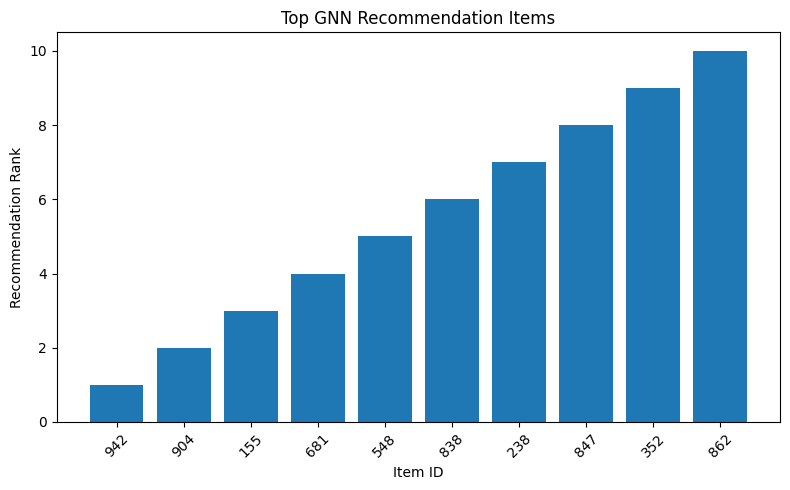

In [29]:
import matplotlib.pyplot as plt
import pandas as pd 

recommended_df = pd.DataFrame({
    "recommended_item_id": recommended_item_ids
})

plt.figure(figsize=(8,5))
plt.bar(
    recommended_df["recommended_item_id"].astype(str), range(1, len(recommended_df)+1)
)

plt.title("Top GNN Recommendation Items")
plt.xlabel("Item ID")
plt.ylabel("Recommendation Rank")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.savefig("GNN_top_recommendations.png")
plt.show()


In [25]:
print(sample_data.columns.to_list())

['visitorid', 'itemid', 'user_id']


In [30]:
recommended_df.to_csv(
    "GNN_Recommendations.csv",index=False
)

print("Saved successfully")

Saved successfully


In [32]:
scores = top_items.values.tolist()

recommendation_scores = pd.DataFrame({
    "recommended_item_id": recommended_item_ids, "score": scores[:len(recommended_item_ids)] 
})

print(recommendation_scores)

   recommended_item_id     score
0                  942  0.018268
1                  904  0.017693
2                  155  0.017514
3                  681  0.017016
4                  548  0.016936
5                  838  0.016663
6                  238  0.016352
7                  847  0.016330
8                  352  0.016220
9                  862  0.016215


In [33]:
recommendation_scores.to_csv("GNN_Recommendations_with_scores.csv",index=False)
print("saved")

saved


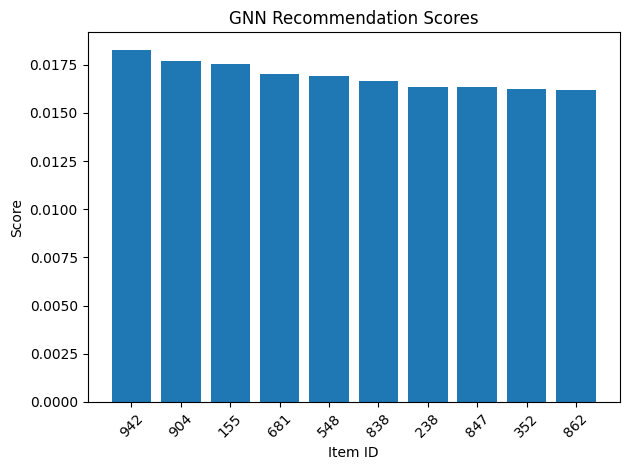

In [34]:
import matplotlib.pyplot as plt

recommendation_scores = recommendation_scores.sort_values(
    by = "score",
    ascending=False
)
 
plt.Figure(figsize=(8,5))

plt.bar(recommendation_scores["recommended_item_id"].astype(str),recommendation_scores["score"])

plt.title("GNN Recommendation Scores")
plt.xlabel("Item ID")
plt.ylabel("Score")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


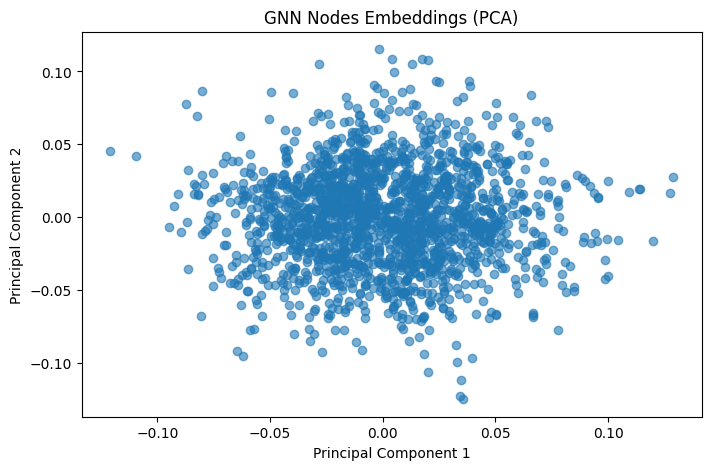

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(
    embeddings.numpy()
)

plt.figure(figsize=(8,5))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    alpha=0.6
)

plt.title("GNN Nodes Embeddings (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("GNN_Embeddings_pca.png")
plt.show()